In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import os
import numpy as np 
import matplotlib.pyplot as plt




## Download train, validation and test dataframes

In [2]:
train_id = "16ADiN0-geWlmkhN04bymFy_N7OA0SPHy"
train_url = f'https://drive.google.com/uc?id={train_id}'
# Load the CSV file into a pandas DataFrame
train_df = pd.read_csv(train_url)
train_df.head()

,File,Encoded_Label
0,n02437312/images/n02437312_229.JPEG,53
1,n02437312/images/n02437312_394.JPEG,53
2,n02437312/images/n02437312_15.JPEG,53
3,n02437312/images/n02437312_62.JPEG,53
4,n02437312/images/n02437312_17.JPEG,53


In [3]:
train_df["Encoded_Label"]

0         53
1         53
2         53
3         53
4         53
        ... 
99995    121
99996    121
99997    121
99998    121
99999    121
Name: Encoded_Label, Length: 100000, dtype: int64

In [4]:
val_id = "1lGkKcAD6Kc7JhfYsa9naVIwwc-MKdXQI"
val_url = f'https://drive.google.com/uc?id={val_id}'
# Load the CSV file into a pandas DataFrame
val_df = pd.read_csv(val_url)
val_df.head()

,File,Encoded_Label
0,val_4526.JPEG,115
1,val_7545.JPEG,88
2,val_1726.JPEG,149
3,val_4997.JPEG,99
4,val_6429.JPEG,149


In [5]:
test_id = "1lOi6xnfVghuzj1fYlIBbLNWWZQvahygQ"
test_url = f'https://drive.google.com/uc?id={test_id}'
# Load the CSV file into a pandas DataFrame
test_df = pd.read_csv(test_url)
test_df.head()

,File
0,val_9240.JPEG
1,val_9308.JPEG
2,val_3262.JPEG
3,val_3528.JPEG
4,val_4147.JPEG


In [6]:
class CSVImageDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df         = df
        self.images_dir = images_dir
        self.transform  = transform
        self.has_labels = "Encoded_Label" in self.df.columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row["File"])
        img = Image.open(img_path).convert("RGB")
        
        if self.transform:
            img = self.transform(img)

        if self.has_labels:
            return img, torch.tensor(row["Encoded_Label"], dtype=torch.long)
        return img

        return img, torch.tensor(label, dtype=torch.long)
    def __len__(self):
        return len(self.df)

In [7]:
MEAN = [0.4802, 0.4481, 0.3975]            # Valores estandar de Tiny ImageNet
STD  = [0.2770, 0.2691, 0.2821]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),           # ConvNeXt fue entrenado en 224x224
    # transforms.RandomCrop(64),            # Tiny ImageNet es 64x64 nativo
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomResizedCrop(224,scale=(0.7, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


# ── Datasets ──────────────────────────────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/"
VAL_DIR = "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/val/images/"

train_dataset = CSVImageDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset   = CSVImageDataset(val_df,   VAL_DIR, transform=test_transform)
test_dataset  = CSVImageDataset(test_df,  VAL_DIR, transform=test_transform)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# ── Sanity check ──────────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # [64, 3, 128, 128]
print(f"Labels shape: {labels.shape}")   # [64]
print(f"Unique labels in batch: {labels.unique()}")

Batch shape : torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])
Unique labels in batch: tensor([  0,  12,  13,  15,  18,  19,  27,  30,  32,  34,  45,  48,  51,  52,
         59,  63,  65,  66,  70,  74,  79,  82,  84,  87,  91,  93,  94,  97,
         98, 105, 108, 114, 122, 127, 131, 132, 139, 141, 143, 145, 150, 151,
        152, 153, 159, 163, 164, 166, 167, 169, 172, 173, 185, 188, 196])


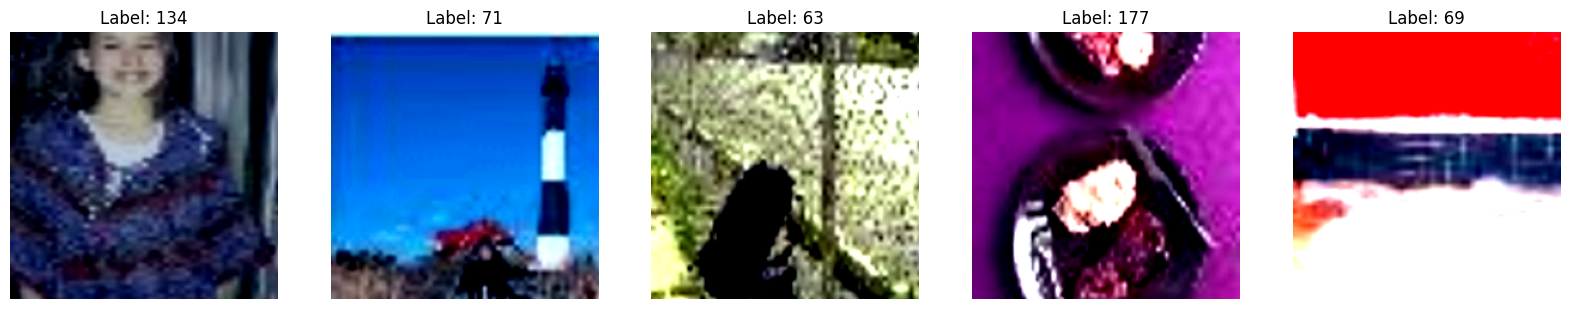

In [8]:
# Plotting the first few images in the batch
images, labels = next(iter(train_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

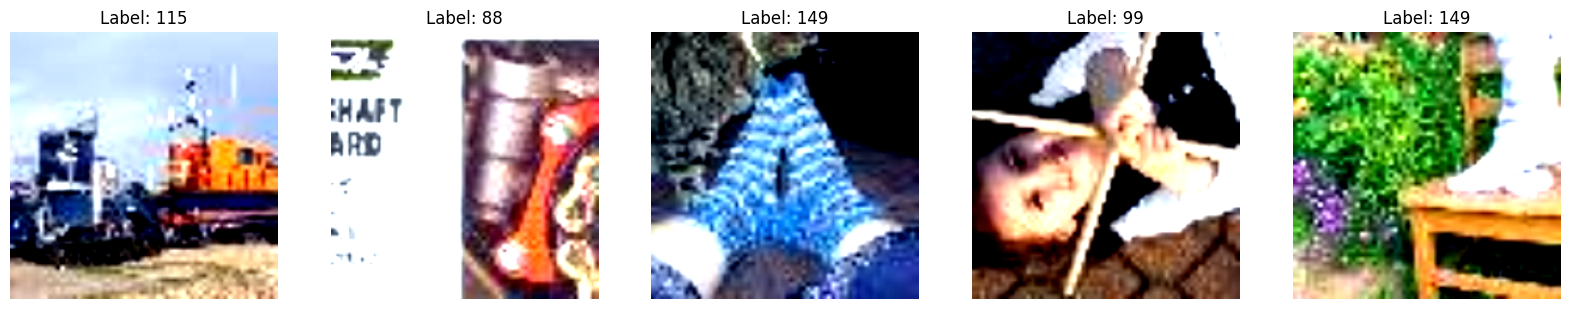

In [9]:
# Plotting the first few images in the batch
images, labels = next(iter(val_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: {int(labels[i])}")
plt.show()

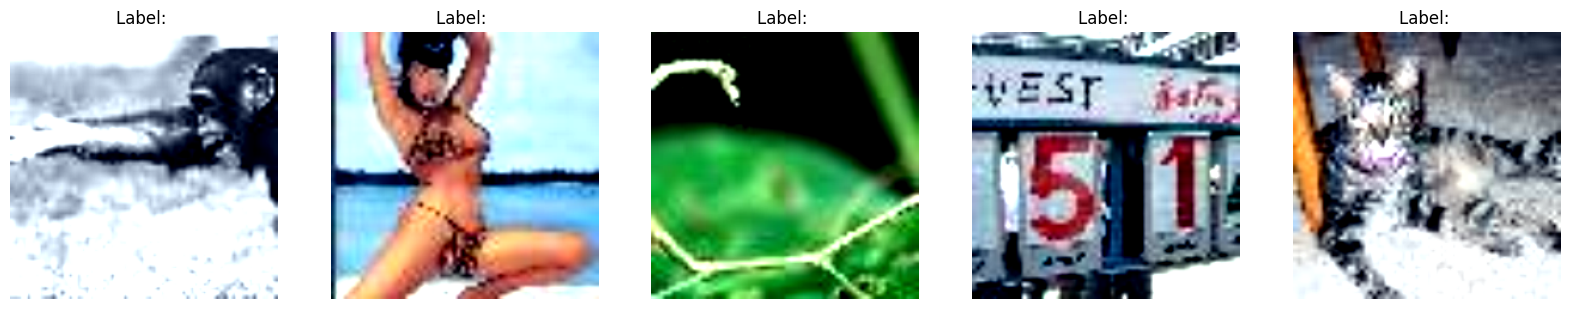

In [10]:
# Plotting the first few images in the batch
images = next(iter(test_loader))

num_images_to_show = 5
plt.figure(figsize=(20, 10))
for i in range(num_images_to_show):
    ax = plt.subplot(1, num_images_to_show, i + 1)
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # undo Normalize [-1,1] -> [0,1]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Label: ")
plt.show()

## Neural network training

Use of a pretrained model.

In [11]:
import torch
import torch.nn as nn
import torchvision
import torchmetrics
import numpy as np
import matplotlib.pyplot as plt
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.data import DataLoader, Subset
from torch.utils.tensorboard import SummaryWriter

torch.manual_seed(123)

2026-05-10 19:35:43.875284: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778441743.898393    1132 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778441743.905249    1132 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778441743.923532    1132 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778441743.923559    1132 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778441743.923561    1132 computation_placer.cc:177] computation placer alr

- Loading a model from the PyTorch Hub: https://pytorch.org/docs/stable/hub.html

In [12]:
entrypoints = torch.hub.list('pytorch/vision', force_reload=True)
for e in entrypoints:
    print(e)

Downloading: "https://github.com/pytorch/vision/zipball/main" to /root/.cache/torch/hub/main.zip
alexnet
convnext_base
convnext_large
convnext_small
convnext_tiny
deeplabv3_mobilenet_v3_large
deeplabv3_resnet101
deeplabv3_resnet50
densenet121
densenet161
densenet169
densenet201
efficientnet_b0
efficientnet_b1
efficientnet_b2
efficientnet_b3
efficientnet_b4
efficientnet_b5
efficientnet_b6
efficientnet_b7
efficientnet_v2_l
efficientnet_v2_m
efficientnet_v2_s
fcn_resnet101
fcn_resnet50
get_model_weights
get_weight
googlenet
inception_v3
lraspp_mobilenet_v3_large
maxvit_t
mc3_18
mnasnet0_5
mnasnet0_75
mnasnet1_0
mnasnet1_3
mobilenet_v2
mobilenet_v3_large
mobilenet_v3_small
mvit_v1_b
mvit_v2_s
r2plus1d_18
r3d_18
raft_large
raft_small
regnet_x_16gf
regnet_x_1_6gf
regnet_x_32gf
regnet_x_3_2gf
regnet_x_400mf
regnet_x_800mf
regnet_x_8gf
regnet_y_128gf
regnet_y_16gf
regnet_y_1_6gf
regnet_y_32gf
regnet_y_3_2gf
regnet_y_400mf
regnet_y_800mf
regnet_y_8gf
resnet101
resnet152
resnet18
resnet34
resnet

In [13]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# Loading ConvNeXt Tiny with pretrained weights
weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
pytorch_model = torch.hub.load('pytorch/vision', 'convnext_tiny', weights=weights)

# Freeze all layers except the final classifier
for param in pytorch_model.parameters():
    param.requires_grad = False

# In ConvNeXt, the final classifier is in pytorch_model.classifier[2]
pytorch_model.classifier[2] = nn.Linear(768, 200)  # 768 is convnext_tiny's in_features
print(pytorch_model)

# Weights associated preprocess
preprocess_transform = weights.transforms()
print(preprocess_transform)

Using cache found in /root/.cache/torch/hub/pytorch_vision_main


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

## Training Loop

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, acc_metric, device):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()

In [15]:
def evaluate(model, loader, criterion, acc_metric, device):
    model.eval()
    acc_metric.reset()
    total_loss = 0.0

    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()

### Stage 1

In [16]:
torch.manual_seed(123)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = pytorch_model.to(device)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=200).to(device)
val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=200).to(device)

writer = SummaryWriter(log_dir="logs/resnet18-two-stage")

In [17]:
STAGE1_EPOCHS = 5

print("--- Stage 1: FC only ---")
for epoch in range(1, STAGE1_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, train_acc, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, val_acc, device)

    writer.add_scalars("Loss",     {"train": tr_loss, "val": vl_loss}, epoch)
    writer.add_scalars("Accuracy", {"train": tr_acc,  "val": vl_acc},  epoch)
    writer.add_scalar("Stage", 1, epoch)

    print(f"Epoch {epoch:02d}/{STAGE1_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

--- Stage 1: FC only ---
Epoch 01/5 | Train Loss: 1.5030  Acc: 0.6681 | Val Loss: 0.7535  Acc: 0.8042
Epoch 02/5 | Train Loss: 1.0061  Acc: 0.7401 | Val Loss: 0.7160  Acc: 0.8145
Epoch 03/5 | Train Loss: 0.9376  Acc: 0.7541 | Val Loss: 0.7070  Acc: 0.8187
Epoch 04/5 | Train Loss: 0.8913  Acc: 0.7639 | Val Loss: 0.7121  Acc: 0.8133
Epoch 05/5 | Train Loss: 0.8625  Acc: 0.7701 | Val Loss: 0.7189  Acc: 0.8167


### Stage 2

In [20]:
import copy

# Unfreezing of last 2 blocks + classifier
for param in model.features[-2:].parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

# Diferential LR: new layers learn faster than unfreezed layers.
optimizer = torch.optim.Adam([
    {'params': model.features[-2:].parameters(), 'lr': 5e-5},
    {'params': model.classifier.parameters(),    'lr': 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.3
)

STAGE2_EPOCHS = 30
TOTAL_EPOCHS  = STAGE1_EPOCHS + STAGE2_EPOCHS
PATIENCE        = 7
patience_counter = 0
best_val_loss   = float('inf')
best_model_wts  = copy.deepcopy(model.state_dict())   # Saving best model

In [21]:
print("\n--- Stage 2: Full fine-tuning ---")
for epoch in range(STAGE1_EPOCHS + 1, TOTAL_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, train_acc, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, val_acc, device)

    scheduler.step(vl_loss)   # Adjust LR based on val_loss

    writer.add_scalars("Loss",     {"train": tr_loss, "val": vl_loss}, epoch)
    writer.add_scalars("Accuracy", {"train": tr_acc,  "val": vl_acc},  epoch)
    writer.add_scalar("LR", optimizer.param_groups[0]['lr'], epoch)

    print(f"Epoch {epoch:02d}/{TOTAL_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    # ── Early stopping  ────────────────────────────
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"  ✓ Nuevo mejor modelo (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping en epoch {epoch}.")
            break

# Best model weights recovery
model.load_state_dict(best_model_wts)
print("Modelo restaurado al mejor checkpoint.")
writer.close()


--- Stage 2: Full fine-tuning ---
Epoch 06/35 | Train Loss: 0.7406  Acc: 0.7973 | Val Loss: 0.6030  Acc: 0.8403 | LR: 5.00e-05
  ✓ Nuevo mejor modelo (val_loss=0.6030)
Epoch 07/35 | Train Loss: 0.6237  Acc: 0.8240 | Val Loss: 0.6043  Acc: 0.8392 | LR: 5.00e-05
Epoch 08/35 | Train Loss: 0.5364  Acc: 0.8468 | Val Loss: 0.6159  Acc: 0.8433 | LR: 5.00e-05
Epoch 09/35 | Train Loss: 0.4568  Acc: 0.8676 | Val Loss: 0.6252  Acc: 0.8413 | LR: 5.00e-05
Epoch 10/35 | Train Loss: 0.3943  Acc: 0.8841 | Val Loss: 0.6284  Acc: 0.8438 | LR: 1.50e-05
Epoch 11/35 | Train Loss: 0.3161  Acc: 0.9062 | Val Loss: 0.6204  Acc: 0.8482 | LR: 1.50e-05
Epoch 12/35 | Train Loss: 0.2912  Acc: 0.9145 | Val Loss: 0.6184  Acc: 0.8473 | LR: 1.50e-05
Epoch 13/35 | Train Loss: 0.2797  Acc: 0.9174 | Val Loss: 0.6193  Acc: 0.8467 | LR: 1.50e-05
  Early stopping en epoch 13.
Modelo restaurado al mejor checkpoint.


In [22]:
test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=200).to(device)
te_loss, te_acc = evaluate(model, test_loader, criterion, test_acc, device)
print(f"\nTest Loss: {te_loss:.4f} | Test Accuracy: {te_acc:.4f}")

ValueError: too many values to unpack (expected 2)

## Test Set — No Labels Available

 The test set does not include ground-truth labels. To evaluate your model
 on the test set, you need to:

 1. Run inference on the test loader to get predictions for each image
 2. Create a CSV with two columns: `File` (the image filename) and `Encoded_Label` (your predicted class)
 3. Submit that CSV for evaluation

 You can generate it like this:


In [23]:
import torch
import pandas as pd

model.eval()
filenames   = test_dataset.df["File"].tolist()
predictions = []

with torch.inference_mode():
 for i, images in enumerate(test_loader):
     images  = images.to(device)
     logits  = model(images)
     preds   = logits.argmax(dim=1).cpu().tolist()
     predictions.extend(preds)

submission = pd.DataFrame({"File": filenames, "Encoded_Label": predictions})
submission.to_csv("submission.csv", index=False)
print(submission.head())

            File  Encoded_Label
0  val_9240.JPEG             55
1  val_9308.JPEG             74
2  val_3262.JPEG             40
3  val_3528.JPEG             65
4  val_4147.JPEG             30


 Make sure the order of `filenames` matches the order images are loaded
 by the test loader — since `shuffle=False`, the order is preserved.

## SHOULD HAVE 0.94 ON ACCURACY